Dataset Preview:
  User_ID Product_ID Product_Category  Purchase    Age Gender     Mood  \
0   U1001       P101         Clothing      4502  46-50      M    Happy   
1   U1001       P104           Beauty       107  18-25      M      Sad   
2   U1001       P105            Books      2655  46-50      F  Neutral   
3   U1001       P102             Home      3439  46-50      M    Happy   
4   U1001       P101         Clothing      4235  18-25      M    Happy   

  Weather Time_of_Day Day_of_Week  Is_Weekend  Previous_Week_Spending  
0   Windy   Afternoon    Saturday           1                     0.0  
1  Cloudy     Evening      Monday           0                  4502.0  
2  Cloudy   Afternoon     Tuesday           0                  4609.0  
3   Rainy       Night    Thursday           0                  7264.0  
4   Sunny       Night     Tuesday           0                 10703.0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (tota

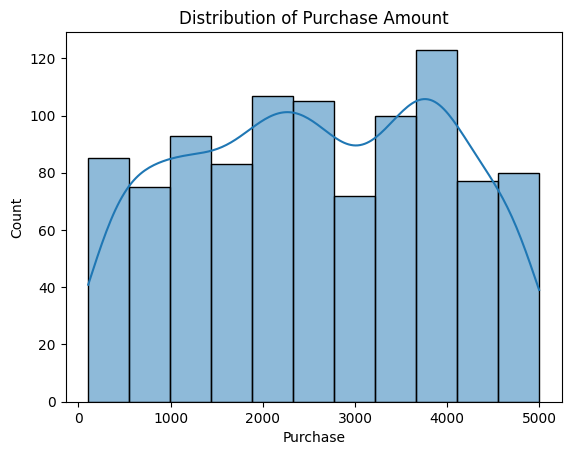

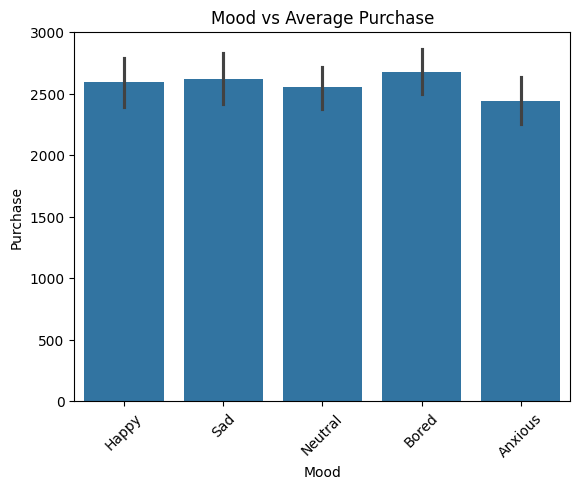

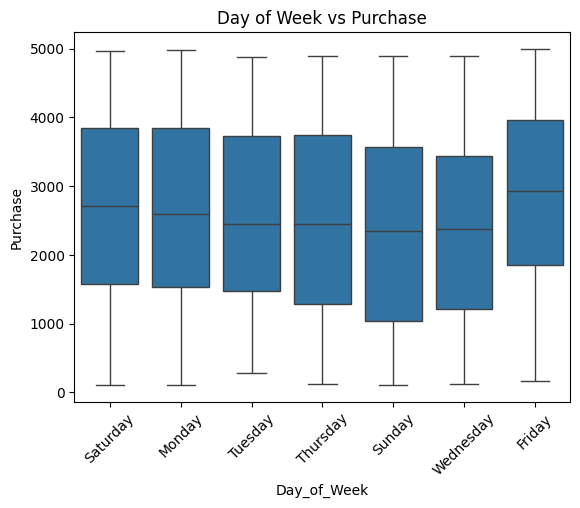

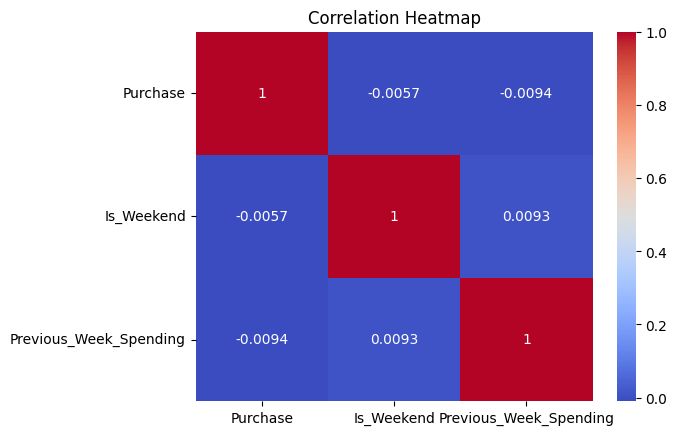


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.50      0.04      0.07        26
           1       0.87      0.99      0.93       174

    accuracy                           0.87       200
   macro avg       0.69      0.52      0.50       200
weighted avg       0.83      0.87      0.82       200


--- Regression Metrics ---
MAE: 1274.3656
RMSE: 1489.0648400237649
R² Score: -0.21147935118050842


In [5]:
# DIGITAL SPENDING TWIN - MACHINE LEARNING

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("customized_spending_data.csv")
print("Dataset Preview:")
print(df.head())
print("\nDataset Info:")
print(df.info())

sns.histplot(df['Purchase'], kde=True)
plt.title("Distribution of Purchase Amount")
plt.show()

sns.barplot(x='Mood', y='Purchase', data=df)
plt.title("Mood vs Average Purchase")
plt.xticks(rotation=45)
plt.show()

sns.boxplot(x='Day_of_Week', y='Purchase', data=df)
plt.title("Day of Week vs Purchase")
plt.xticks(rotation=45)
plt.show()

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

df['Will_Buy'] = (df['Purchase'] > 1000).astype(int)

X = pd.get_dummies(df[['Mood', 'Weather', 'Time_of_Day', 'Day_of_Week',
                       'Product_Category', 'Gender', 'Age']], drop_first=True)
X['Previous_Week_Spending'] = df['Previous_Week_Spending']
X['Is_Weekend'] = df['Is_Weekend']
y_class = df['Will_Buy']

X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=42)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

y_reg = df['Purchase']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.2, random_state=42)

reg = RandomForestRegressor()
reg.fit(X_train_r, y_train_r)
y_pred_r = reg.predict(X_test_r)

print("\n--- Regression Metrics ---")
print("MAE:", mean_absolute_error(y_test_r, y_pred_r))
mse = mean_squared_error(y_test_r, y_pred_r)
rmse = mse ** 0.5
print("RMSE:", rmse)
print("R² Score:", r2_score(y_test_r, y_pred_r))
